# Predicting Movie Ratings Using Film Features
**DSA 210 – Introduction to Data Science | Yağız Mert Göçmen**

## 0. Imports & Configuration

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import ast
import warnings
from scipy import stats

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)

---
## 1. Data Loading & Merging

In [204]:
movies   = pd.read_csv('../data/raw/tmdb_5000_movies.csv')
credits  = pd.read_csv('../data/raw/tmdb_5000_credits.csv')

print('Movies shape  :', movies.shape)
print('Credits shape :', credits.shape)
movies.head(2)

Movies shape  : (4803, 20)
Credits shape : (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500


In [205]:
# Merge on movie title
credits = credits.rename(columns={'movie_id': 'id'})
df = movies.merge(credits[['id', 'cast', 'crew']], on='id', how='left')
print('Merged shape:', df.shape)
df.head(2)

Merged shape: (4803, 22)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


---
## 2. Data Cleaning & Preprocessing

### 2.1 Parse JSON-encoded columns

In [206]:
def safe_parse(val):
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []

def extract_names(val, key='name', limit=None):
    parsed = safe_parse(val) if isinstance(val, str) else val
    names = [d[key] for d in parsed if key in d]
    return names[:limit] if limit else names

def extract_director(crew_val):
    crew = safe_parse(crew_val) if isinstance(crew_val, str) else crew_val
    for member in crew:
        if member.get('job') == 'Director':
            return member.get('name')
    return None

df['genres_list']    = df['genres'].apply(extract_names)
df['keywords_list']  = df['keywords'].apply(extract_names)
df['cast_list']      = df['cast'].apply(lambda x: extract_names(x, limit=5))
df['director']       = df['crew'].apply(extract_director)

# Primary genre (first listed)
df['primary_genre'] = df['genres_list'].apply(lambda g: g[0] if g else 'Unknown')

print('Sample genres_list:')
df[['title', 'genres_list', 'primary_genre', 'director']].head(5)

Sample genres_list:


,title,genres_list,primary_genre,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]",Action,James Cameron
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]",Adventure,Gore Verbinski
2,Spectre,"[Action, Adventure, Crime]",Action,Sam Mendes
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]",Action,Christopher Nolan
4,John Carter,"[Action, Adventure, Science Fiction]",Action,Andrew Stanton


### 2.2 Handle missing values and zero-encoded entries

In [207]:
# Release year
df['release_year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year

# Budget and revenue: 0 means 'not available' in TMDB
df['budget']  = df['budget'].replace(0, np.nan)
df['revenue'] = df['revenue'].replace(0, np.nan)

# Log-transform skewed financials (preserve NaN)
df['log_budget']  = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_votes']   = np.log1p(df['vote_count'])

# Missing value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing)

Columns with missing values:
homepage        3091
revenue         1427
log_revenue     1427
budget          1037
log_budget      1037
tagline          844
director          30
overview           3
runtime            2
release_date       1
release_year       1
dtype: int64


### 2.3 Remove invalid / low-quality rows

In [208]:
# Keep only Released movies with at least 10 votes and a valid runtime
df_clean = df[
    (df['status'] == 'Released') &
    (df['vote_count'] >= 10) &
    (df['runtime'] > 0) &
    (df['vote_average'] > 0)
].copy()

print(f'Rows before cleaning : {len(df)}')
print(f'Rows after cleaning  : {len(df_clean)}')
print(f'Dropped              : {len(df) - len(df_clean)}')

Rows before cleaning : 4803
Rows after cleaning  : 4384
Dropped              : 419


### 2.4 Outlier removal – IQR method on numerical features

In [209]:
def remove_outliers_iqr(data, col, multiplier=3.0):
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
    return data[(data[col] >= lower) & (data[col] <= upper)]

before = len(df_clean)
for col in ['runtime', 'vote_average', 'popularity']:
    df_clean = remove_outliers_iqr(df_clean, col)

print(f'Rows after IQR outlier removal: {len(df_clean)}  (removed {before - len(df_clean)})')
df_clean.describe()[['budget', 'revenue', 'runtime', 'vote_average', 'vote_count', 'popularity']]

Rows after IQR outlier removal: 4274  (removed 110)


,budget,revenue,runtime,vote_average,vote_count,popularity
count,3.540000e+03,3.213000e+03,4274.000000,4274.000000,4274.000000,4274.000000
mean,3.601811e+07,1.045109e+08,107.450398,6.206411,656.887225,20.751578
std,3.916280e+07,1.454710e+08,18.301643,0.877109,998.274930,19.307883
min,1.000000e+00,5.000000e+00,25.000000,2.700000,10.000000,0.011697
25%,9.000000e+06,1.617896e+07,94.000000,5.700000,83.000000,6.471491
50%,2.400000e+07,5.116411e+07,104.000000,6.300000,281.000000,14.615548
75%,5.000000e+07,1.319404e+08,118.000000,6.800000,775.750000,29.144949
max,2.700000e+08,1.215440e+09,191.000000,8.400000,10099.000000,101.187052


### 2.5 Final feature selection

In [210]:
FEATURES = [
    'title', 'vote_average', 'vote_count', 'log_votes',
    'budget', 'log_budget', 'revenue', 'log_revenue',
    'runtime', 'popularity', 'release_year',
    'primary_genre', 'genres_list', 'director', 'original_language'
]

df_final = df_clean[FEATURES].reset_index(drop=True)
print('Final dataset shape:', df_final.shape)
df_final.head(5)

Final dataset shape: (4274, 15)


,title,vote_average,vote_count,log_votes,budget,log_budget,revenue,log_revenue,runtime,popularity,release_year,primary_genre,genres_list,director,original_language
0,John Carter,6.1,2124,7.661527,260000000.0,19.376192,284139100.0,19.464974,132.0,43.926995,2012.0,Action,"[Action, Adventure, Science Fiction]",Andrew Stanton,en
1,Tangled,7.4,3330,8.111028,260000000.0,19.376192,591794936.0,20.198671,100.0,48.681969,2010.0,Animation,"[Animation, Family]",Byron Howard,en
2,Harry Potter and the Half-Blood Prince,7.4,5293,8.574329,250000000.0,19.336971,933959197.0,20.654943,153.0,98.885637,2009.0,Adventure,"[Adventure, Fantasy, Family]",David Yates,en
3,Superman Returns,5.4,1400,7.244942,270000000.0,19.413933,391081192.0,19.784426,154.0,57.925623,2006.0,Adventure,"[Adventure, Fantasy, Action, Science Fiction]",Bryan Singer,en
4,The Lone Ranger,5.9,2311,7.745868,255000000.0,19.356774,89289910.0,18.307399,149.0,49.046956,2013.0,Action,"[Action, Adventure, Western]",Gore Verbinski,en


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Distribution of movie ratings

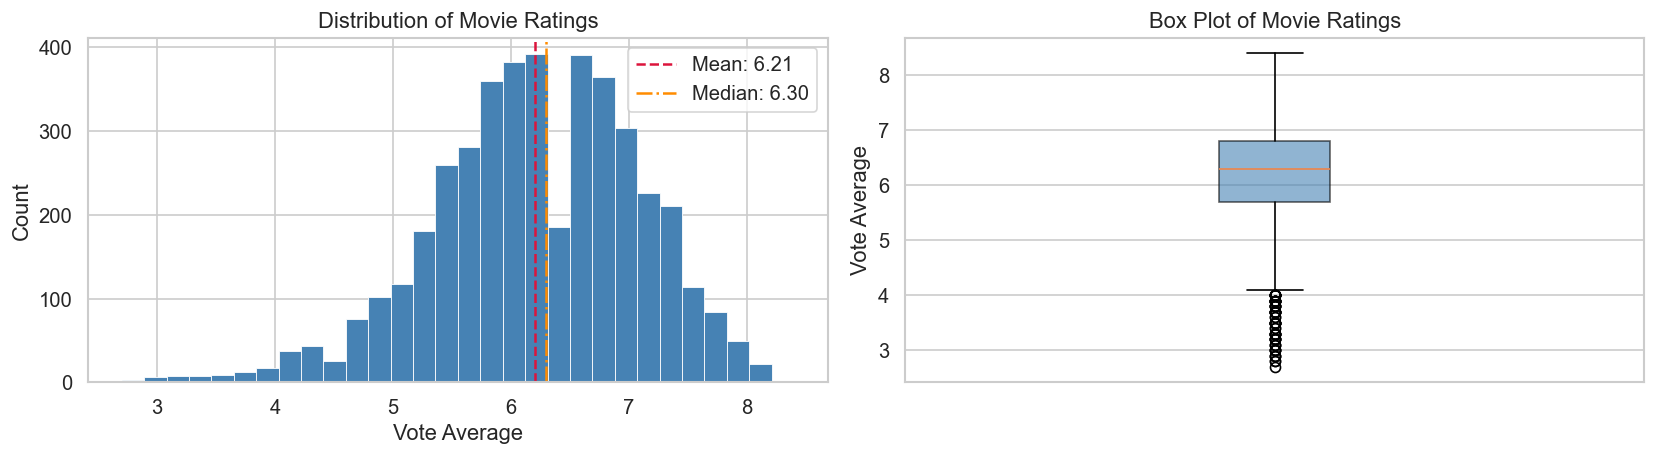

count    4274.000
mean        6.206
std         0.877
min         2.700
25%         5.700
50%         6.300
75%         6.800
max         8.400
Name: vote_average, dtype: float64


In [211]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df_final['vote_average'], bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df_final['vote_average'].mean(),   color='crimson',  linestyle='--', label=f"Mean: {df_final['vote_average'].mean():.2f}")
axes[0].axvline(df_final['vote_average'].median(), color='darkorange', linestyle='-.',  label=f"Median: {df_final['vote_average'].median():.2f}")
axes[0].set_xlabel('Vote Average')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Movie Ratings')
axes[0].legend()

# Box plot
axes[1].boxplot(df_final['vote_average'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('Vote Average')
axes[1].set_title('Box Plot of Movie Ratings')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print(df_final['vote_average'].describe().round(3))

### 3.2 Ratings over time (by release year)

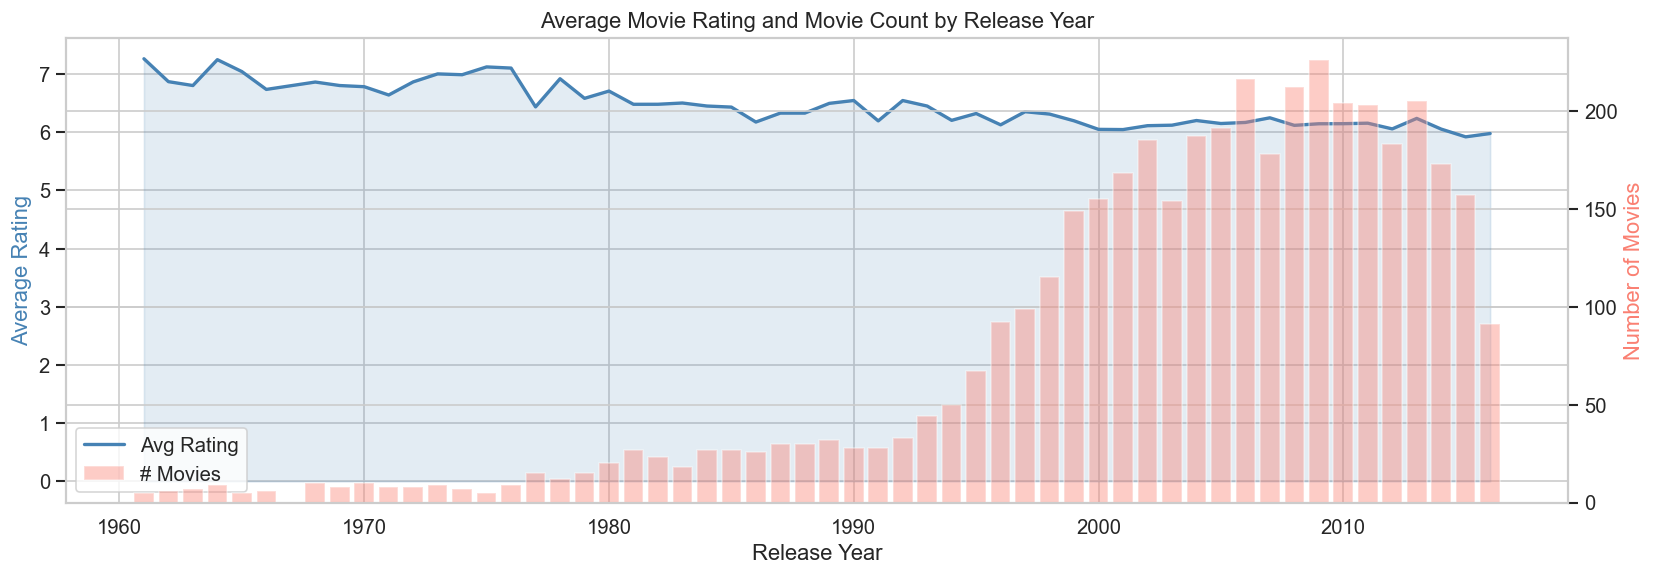

In [212]:
yearly = (
    df_final.dropna(subset=['release_year'])
    .groupby('release_year')['vote_average']
    .agg(['mean', 'count'])
    .reset_index()
)
yearly = yearly[yearly['count'] >= 5]  # only years with 5+ movies

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(yearly['release_year'], yearly['mean'], color='steelblue', linewidth=2, label='Avg Rating')
ax1.fill_between(yearly['release_year'], yearly['mean'], alpha=0.15, color='steelblue')
ax2.bar(yearly['release_year'], yearly['count'], color='salmon', alpha=0.4, label='# Movies')

ax1.set_xlabel('Release Year')
ax1.set_ylabel('Average Rating', color='steelblue')
ax2.set_ylabel('Number of Movies', color='salmon')
ax1.set_title('Average Movie Rating and Movie Count by Release Year')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.show()

### 3.3 Ratings by primary genre

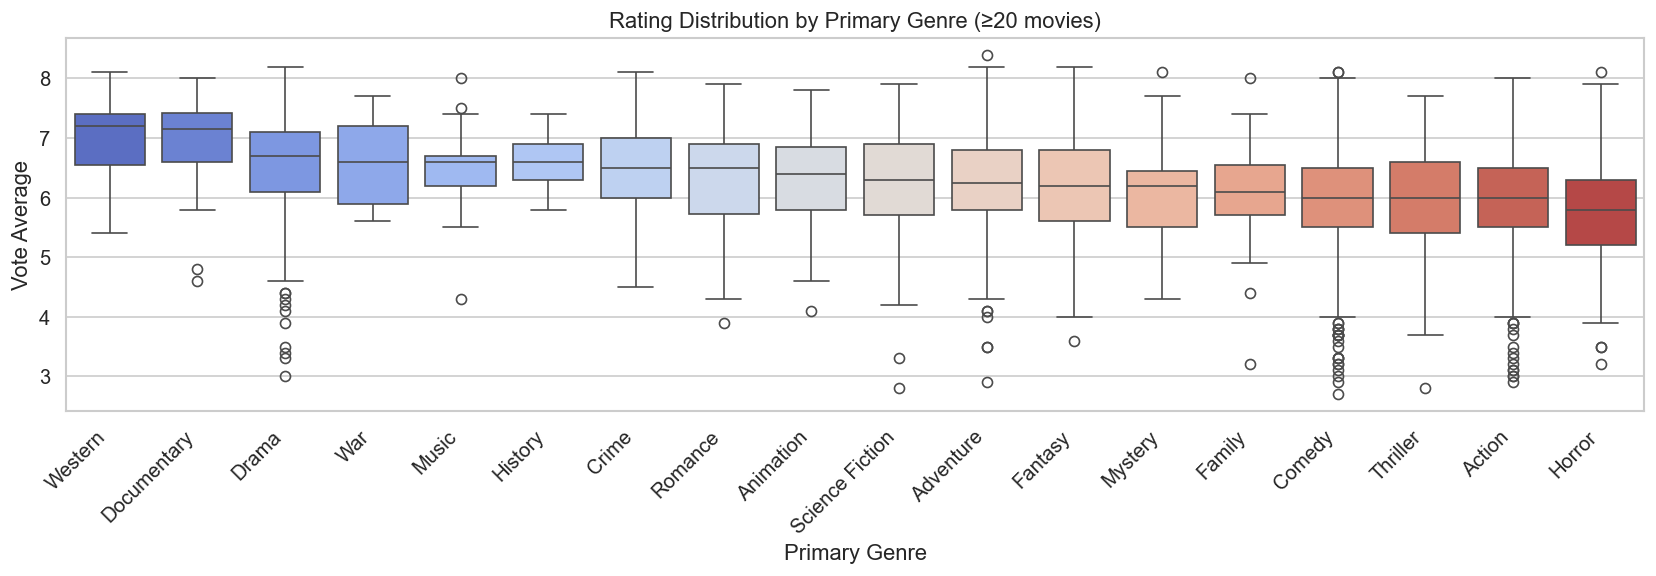

  primary_genre     mean  median  count
        Western 6.986957    7.20     23
    Documentary 6.953846    7.15     52
          Drama 6.579330    6.70   1045
            War 6.571429    6.60     21
          Music 6.486207    6.60     29
        History 6.590476    6.60     21
          Crime 6.516940    6.50    183
        Romance 6.304255    6.50     94
      Animation 6.359459    6.40    111
Science Fiction 6.215854    6.30     82
      Adventure 6.250974    6.25    308
        Fantasy 6.143119    6.20    109
        Mystery 6.097436    6.20     39
         Family 6.053488    6.10     43
         Comedy 5.991954    6.00    957
       Thriller 5.939884    6.00    173
         Action 5.958974    6.00    702
         Horror 5.773118    5.80    279


In [213]:
genre_stats = (
    df_final.groupby('primary_genre')['vote_average']
    .agg(['mean', 'median', 'count'])
    .reset_index()
    .query('count >= 20')
    .sort_values('median', ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 5))
genre_order = genre_stats['primary_genre'].tolist()

sns.boxplot(
    data=df_final[df_final['primary_genre'].isin(genre_order)],
    x='primary_genre', y='vote_average',
    order=genre_order, palette='coolwarm', ax=ax
)
ax.set_xlabel('Primary Genre')
ax.set_ylabel('Vote Average')
ax.set_title('Rating Distribution by Primary Genre (≥20 movies)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(genre_stats.to_string(index=False))

### 3.4 Correlations between numerical features and rating

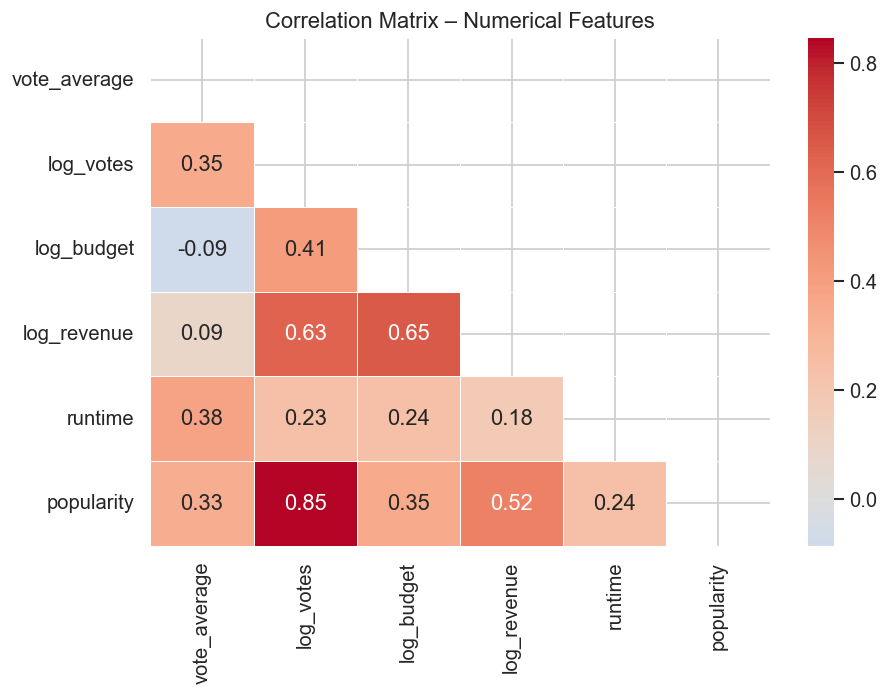


Correlation with vote_average:
runtime        0.379
log_votes      0.351
popularity     0.332
log_revenue    0.087
log_budget    -0.085
Name: vote_average, dtype: float64


In [214]:
num_cols = ['vote_average', 'log_votes', 'log_budget', 'log_revenue', 'runtime', 'popularity']
corr = df_final[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix – Numerical Features')
plt.tight_layout()
plt.show()

print('\nCorrelation with vote_average:')
print(corr['vote_average'].drop('vote_average').sort_values(ascending=False).round(3))

### 3.5 Scatter plots: Vote count, Budget, and Revenue vs Rating

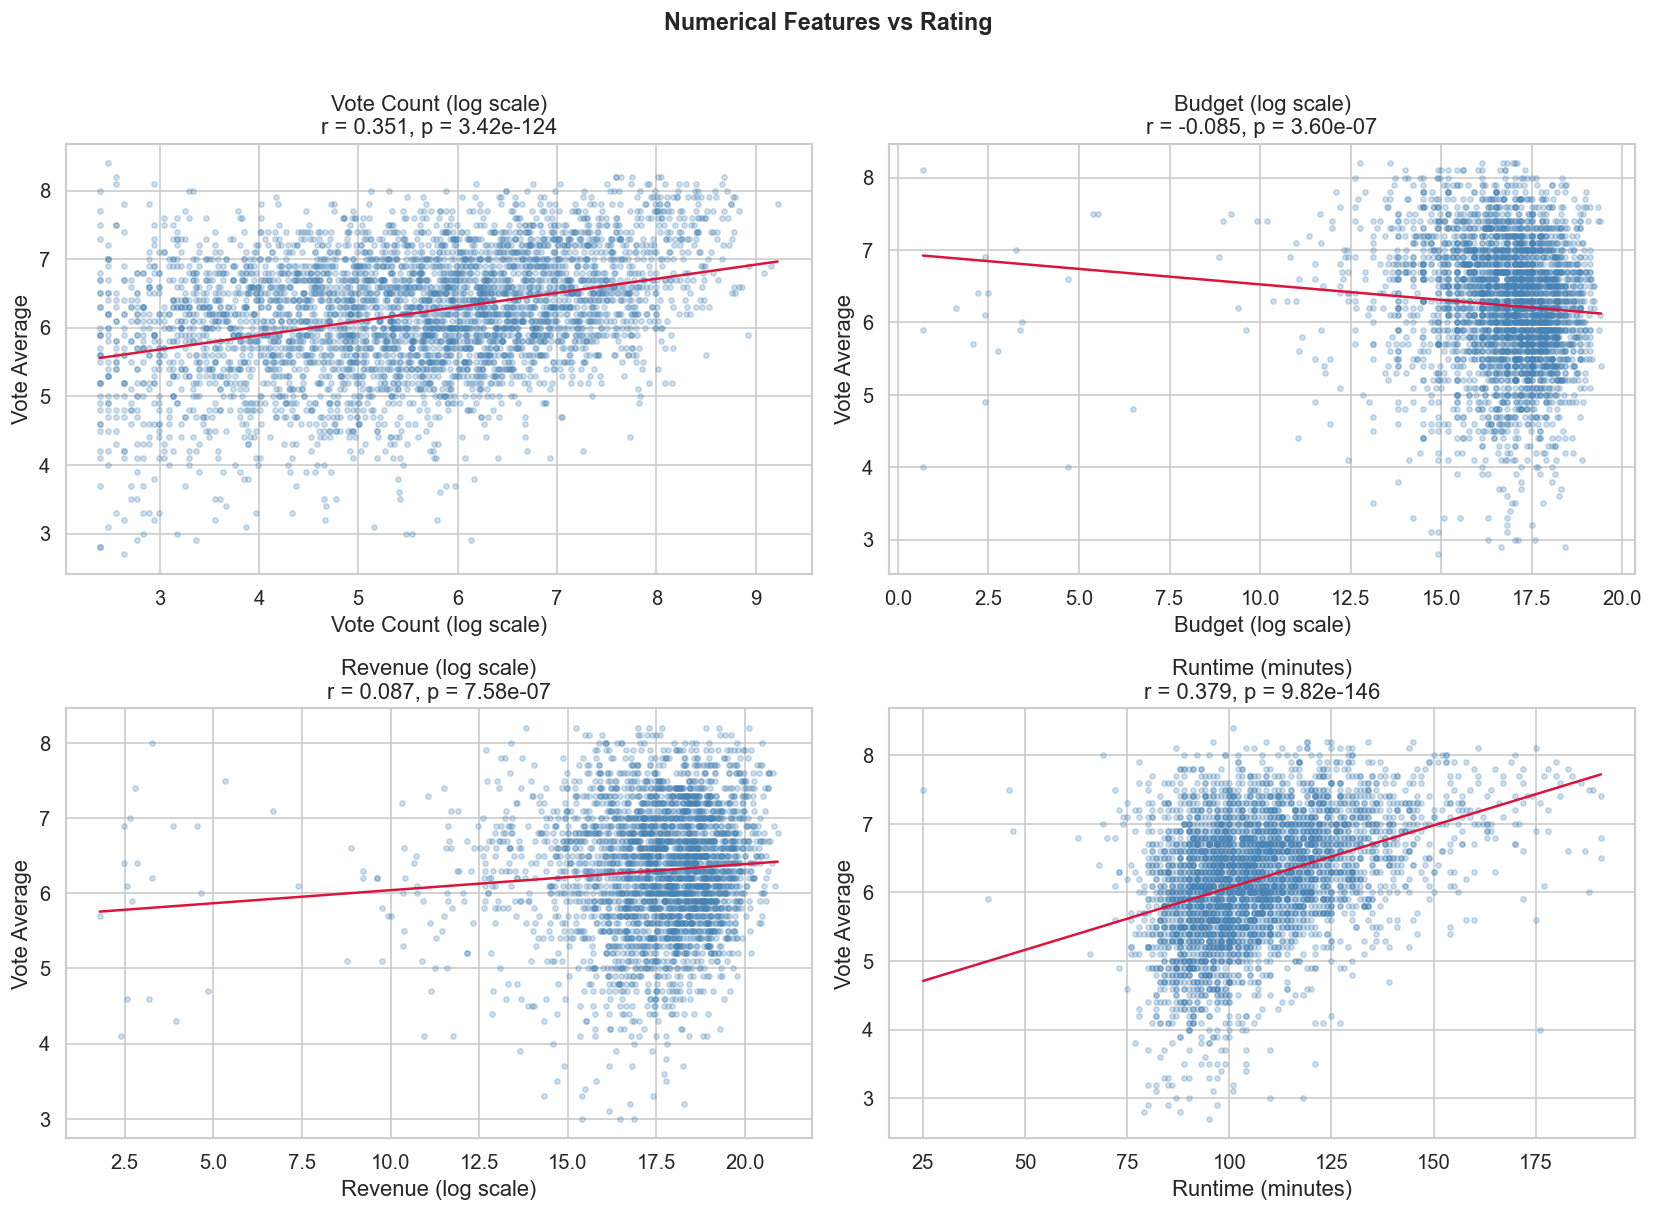

In [215]:
scatter_pairs = [
    ('log_votes',   'Vote Count (log scale)'),
    ('log_budget',  'Budget (log scale)'),
    ('log_revenue', 'Revenue (log scale)'),
    ('runtime',     'Runtime (minutes)'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (xcol, xlabel) in zip(axes, scatter_pairs):
    sub = df_final[['vote_average', xcol]].dropna()
    ax.scatter(sub[xcol], sub['vote_average'], alpha=0.25, s=10, color='steelblue')
    # Regression line
    m, b = np.polyfit(sub[xcol], sub['vote_average'], 1)
    x_line = np.linspace(sub[xcol].min(), sub[xcol].max(), 200)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5)
    r, p = stats.pearsonr(sub[xcol], sub['vote_average'])
    ax.set_title(f'{xlabel}\nr = {r:.3f}, p = {p:.2e}')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Vote Average')

plt.suptitle('Numerical Features vs Rating', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Language distribution and rating comparison

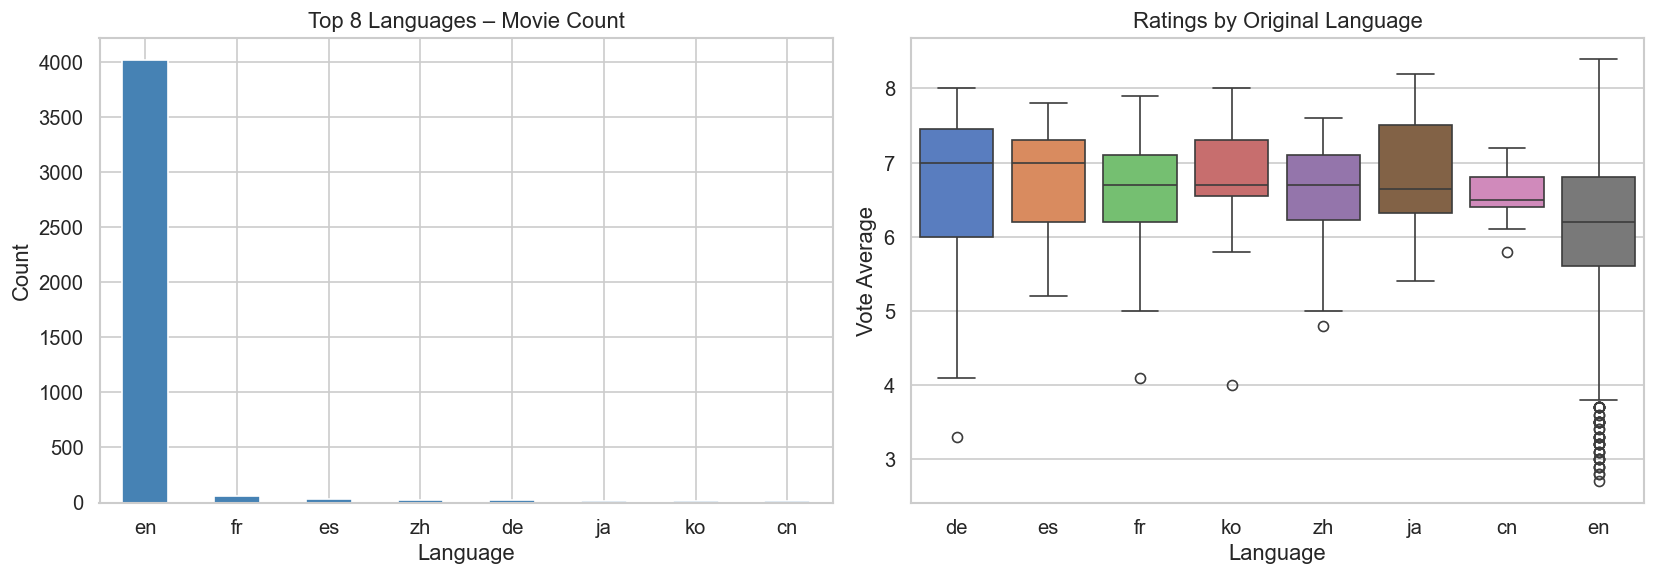

In [216]:
lang_counts = df_final['original_language'].value_counts()
top_langs = lang_counts.head(8).index.tolist()
df_lang = df_final[df_final['original_language'].isin(top_langs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar – movie count by language
lang_counts.head(8).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 8 Languages – Movie Count')
axes[0].set_xlabel('Language')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Box – rating by language
lang_order = (
    df_lang.groupby('original_language')['vote_average']
    .median().sort_values(ascending=False).index.tolist()
)
sns.boxplot(data=df_lang, x='original_language', y='vote_average',
            order=lang_order, palette='muted', ax=axes[1])
axes[1].set_title('Ratings by Original Language')
axes[1].set_xlabel('Language')
axes[1].set_ylabel('Vote Average')

plt.tight_layout()
plt.show()

### 3.7 Budget tiers vs Rating

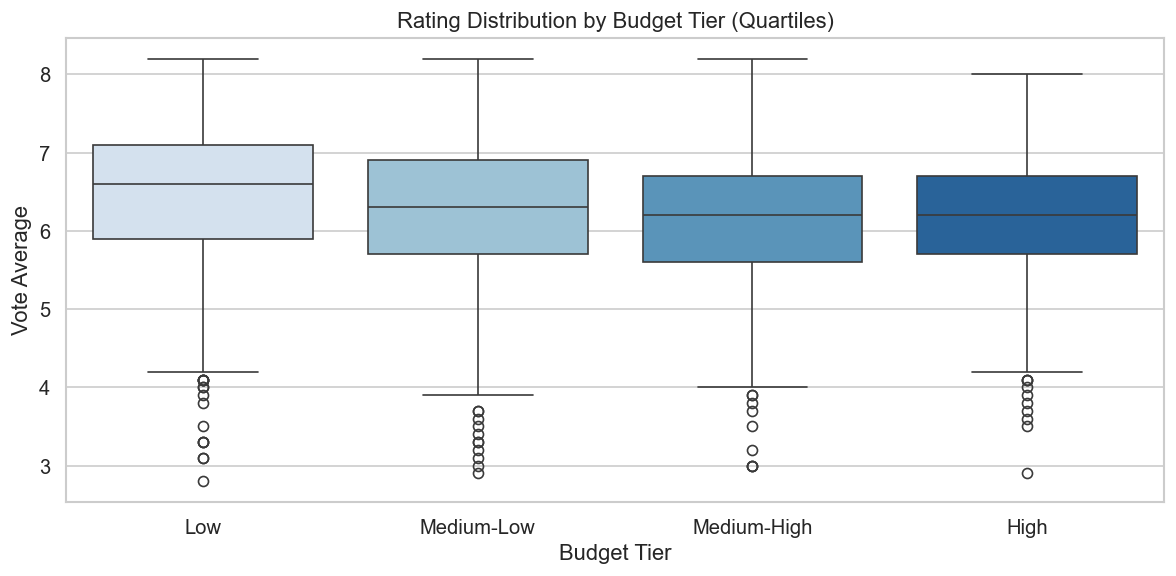

              mean  median  count
budget_tier                      
Low          6.419     6.6    893
Medium-Low   6.226     6.3    893
Medium-High  6.158     6.2    937
High         6.158     6.2    817


In [217]:
budget_sub = df_final.dropna(subset=['budget']).copy()
budget_sub['budget_tier'] = pd.qcut(
    budget_sub['budget'], q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=budget_sub, x='budget_tier', y='vote_average',
            palette='Blues', ax=ax)
ax.set_title('Rating Distribution by Budget Tier (Quartiles)')
ax.set_xlabel('Budget Tier')
ax.set_ylabel('Vote Average')
plt.tight_layout()
plt.show()

print(budget_sub.groupby('budget_tier')['vote_average']
      .agg(['mean', 'median', 'count']).round(3))

---
## 4. Hypothesis Testing

We test four concrete hypotheses derived from the project proposal.

### H1 – Vote count is positively correlated with rating

**H₀:** Pearson correlation between log(vote_count) and vote_average = 0  
**H₁:** The correlation is significantly positive  
**Test:** Pearson correlation t-test (one-tailed)

In [218]:
sub = df_final[['log_votes', 'vote_average']].dropna()
r, p_two = stats.pearsonr(sub['log_votes'], sub['vote_average'])
p_one = p_two / 2

print('H1: vote_count (log) vs vote_average')
print(f'  Pearson r = {r:.4f}')
print(f'  Two-tailed p = {p_two:.4e}')
print(f'  One-tailed p = {p_one:.4e}')
print(f'  n = {len(sub)}')
print()
alpha = 0.05
if p_one < alpha and r > 0:
    print(f'REJECT H₀ at α={alpha}. Positive correlation is statistically significant.')
else:
    print(f'FAIL TO REJECT H₀ at α={alpha}.')

H1: vote_count (log) vs vote_average
  Pearson r = 0.3511
  Two-tailed p = 3.4183e-124
  One-tailed p = 1.7091e-124
  n = 4274

REJECT H₀ at α=0.05. Positive correlation is statistically significant.


### H2 – High-budget films are rated differently from low-budget films

**H₀:** Mean rating of high-budget films = mean rating of low-budget films  
**H₁:** The means differ  
**Test:** Welch's t-test (two-tailed); high = top 25%, low = bottom 25% by budget

In [219]:
budget_data = df_final.dropna(subset=['budget'])
q25 = budget_data['budget'].quantile(0.25)
q75 = budget_data['budget'].quantile(0.75)

low_budget  = budget_data[budget_data['budget'] <= q25]['vote_average']
high_budget = budget_data[budget_data['budget'] >= q75]['vote_average']

t_stat, p_val = stats.ttest_ind(high_budget, low_budget, equal_var=False)

print('H2: High-budget vs Low-budget ratings (Welch t-test)')
print(f'  Low  budget  → mean = {low_budget.mean():.3f},  n = {len(low_budget)}')
print(f'  High budget  → mean = {high_budget.mean():.3f}, n = {len(high_budget)}')
print(f'  t = {t_stat:.4f},  p = {p_val:.4e}')
print()
if p_val < alpha:
    print(f'REJECT H₀ at α={alpha}. Significant rating difference between budget tiers.')
else:
    print(f'FAIL TO REJECT H₀ at α={alpha}.')

H2: High-budget vs Low-budget ratings (Welch t-test)
  Low  budget  → mean = 6.419,  n = 893
  High budget  → mean = 6.144, n = 918
  t = -6.8854,  p = 8.0254e-12

REJECT H₀ at α=0.05. Significant rating difference between budget tiers.


### H3 – Genre has a significant effect on movie rating

**H₀:** Mean ratings are equal across all primary genres  
**H₁:** At least one genre has a significantly different mean rating  
**Test:** One-way ANOVA (followed by Tukey HSD for post-hoc inspection)

In [220]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

genre_for_test = (
    df_final.groupby('primary_genre')
    .filter(lambda x: len(x) >= 20)
)[['primary_genre', 'vote_average']].dropna()

groups = [g['vote_average'].values for _, g in genre_for_test.groupby('primary_genre')]
f_stat, p_val_anova = stats.f_oneway(*groups)

print('H3: One-way ANOVA – Rating across genres')
print(f'  F-statistic = {f_stat:.4f},  p = {p_val_anova:.4e}')
print(f'  Groups (genres) = {len(groups)}')
print()
if p_val_anova < alpha:
    print(f'REJECT H₀ at α={alpha}. Genre significantly affects rating.')
else:
    print(f'FAIL TO REJECT H₀ at α={alpha}.')

print('\nTukey HSD Post-Hoc (top significant pairs)')
tukey = pairwise_tukeyhsd(
    endog=genre_for_test['vote_average'],
    groups=genre_for_test['primary_genre'],
    alpha=0.05
)
tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)
print(tukey_df[tukey_df['reject'] == True].head(10).to_string(index=False))

H3: One-way ANOVA – Rating across genres
  F-statistic = 31.9992,  p = 3.7999e-98
  Groups (genres) = 18

REJECT H₀ at α=0.05. Genre significantly affects rating.

Tukey HSD Post-Hoc (top significant pairs)
   group1      group2  meandiff  p-adj   lower   upper  reject
   Action   Adventure    0.2920 0.0000  0.0947  0.4893    True
   Action   Animation    0.4005 0.0003  0.1057  0.6953    True
   Action       Crime    0.5580 0.0000  0.3184  0.7975    True
   Action Documentary    0.9949 0.0000  0.5801  1.4097    True
   Action       Drama    0.6204 0.0000  0.4795  0.7612    True
   Action     Romance    0.3453 0.0171  0.0283  0.6623    True
   Action     Western    1.0280 0.0000  0.4164  1.6396    True
Adventure      Comedy   -0.2590 0.0003 -0.4481 -0.0699    True
Adventure Documentary    0.7029 0.0000  0.2701  1.1356    True
Adventure       Drama    0.3284 0.0000  0.1412  0.5155    True


### H4 – English-language films vs non-English films difference

**H₀:** Mean rating of English films ≤ mean rating of non-English films  
**H₁:** English films have a higher mean rating  
**Test:** Welch's t-test (one-tailed)

In [221]:
en     = df_final[df_final['original_language'] == 'en']['vote_average'].dropna()
non_en = df_final[df_final['original_language'] != 'en']['vote_average'].dropna()

t_stat, p_two = stats.ttest_ind(en, non_en, equal_var=False)
p_one = p_two / 2

print('H4: English vs Non-English film ratings (Welch t-test, one-tailed)')
print(f'  English     → mean = {en.mean():.3f},  n = {len(en)}')
print(f'  Non-English → mean = {non_en.mean():.3f}, n = {len(non_en)}')
print(f'  t = {t_stat:.4f},  one-tailed p = {p_one:.4e}')
print()
if p_one < alpha and t_stat > 0:
    print(f'REJECT H₀ at α={alpha}. English films are rated significantly higher.')
elif p_one < alpha and t_stat < 0:
    print(f'REJECT H₀ at α={alpha}. Non-English films are rated significantly higher (opposite direction).')
else:
    print(f'FAIL TO REJECT H₀ at α={alpha}.')

H4: English vs Non-English film ratings (Welch t-test, one-tailed)
  English     → mean = 6.174,  n = 4023
  Non-English → mean = 6.727, n = 251
  t = -10.2549,  one-tailed p = 1.6245e-21

REJECT H₀ at α=0.05. Non-English films are rated significantly higher (opposite direction).


---
## 5. Machine Learning

Six regression models are trained and compared:
- **Linear Regression** – baseline
- **Ridge / Lasso** – regularized linear models
- **Decision Tree** – simple non-linear baseline
- **Random Forest** – ensemble of trees
- **Gradient Boosting** – sequential boosting
- **XGBoost** – optimized gradient boosting

Evaluation: **RMSE** and **R²** on a held-out 20% test set.

### 5.1 Additional imports

In [222]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

### 5.2 Feature preparation

In [223]:
# group rare languages into 'other'
top_langs = df_final['original_language'].value_counts().head(5).index
df_final['lang_grouped'] = df_final['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)

NUM_COLS = ['log_votes', 'log_budget', 'log_revenue', 'runtime', 'popularity', 'release_year']
CAT_COLS = ['primary_genre', 'lang_grouped']

df_ml = df_final[NUM_COLS + CAT_COLS + ['vote_average']].copy()

# impute missing numerical values with median
imputer = SimpleImputer(strategy='median')
X_num = imputer.fit_transform(df_ml[NUM_COLS])

# one-hot encode categoricals
cat_dummies  = pd.get_dummies(df_ml[CAT_COLS])
feature_names = NUM_COLS + cat_dummies.columns.tolist()

X = np.hstack([X_num, cat_dummies.values]).astype(float)
y = df_ml['vote_average'].values

print(f'Feature matrix : {X.shape}')
print(f'Total features : {len(feature_names)}')

Feature matrix : (4274, 32)
Total features : 32


### 5.3 Train / test split

In [224]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

# scaled version for linear models
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]}   Test: {X_test.shape[0]}')

Train: 3419   Test: 855


### 5.4 Model training & evaluation

In [225]:
# linear models use scaled features, tree models use raw
LINEAR_MODELS = {'Linear Regression', 'Ridge', 'Lasso'}

models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.01),
    'Decision Tree':     DecisionTreeRegressor(max_depth=6, random_state=SEED),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=SEED),
    'XGBoost':           XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0),
}

results     = {}
predictions = {}
trained     = {}

for name, model in models.items():
    Xtr = X_train_sc if name in LINEAR_MODELS else X_train
    Xte = X_test_sc  if name in LINEAR_MODELS else X_test

    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    results[name]     = {'RMSE': round(rmse, 4), 'R²': round(r2, 4)}
    predictions[name] = y_pred
    trained[name]     = model
    print(f'{name:22s}  RMSE: {rmse:.4f}   R²: {r2:.4f}')

print()
results_df = pd.DataFrame(results).T.sort_values('RMSE')
print(results_df)

Linear Regression       RMSE: 0.6766   R²: 0.3811
Ridge                   RMSE: 0.6763   R²: 0.3817
Lasso                   RMSE: 0.6785   R²: 0.3777
Decision Tree           RMSE: 0.7475   R²: 0.2448
Random Forest           RMSE: 0.6576   R²: 0.4154
Gradient Boosting       RMSE: 0.6503   R²: 0.4284
XGBoost                 RMSE: 0.6918   R²: 0.3530

                     RMSE      R²
Gradient Boosting  0.6503  0.4284
Random Forest      0.6576  0.4154
Ridge              0.6763  0.3817
Linear Regression  0.6766  0.3811
Lasso              0.6785  0.3777
XGBoost            0.6918  0.3530
Decision Tree      0.7475  0.2448


### 5.5 Cross-validation (5-fold) on best models

In [226]:
# check if tree model scores hold up under CV
cv_models = {
    'Random Forest':     trained['Random Forest'],
    'Gradient Boosting': trained['Gradient Boosting'],
    'XGBoost':           trained['XGBoost'],
}

print('5-fold CV  (neg RMSE -> positive):')
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    print(f'  {name:22s}  mean RMSE: {rmse_scores.mean():.4f}  std: {rmse_scores.std():.4f}')

5-fold CV  (neg RMSE -> positive):
  Random Forest           mean RMSE: 0.6825  std: 0.0895
  Gradient Boosting       mean RMSE: 0.6700  std: 0.0864
  XGBoost                 mean RMSE: 0.7089  std: 0.0847


### 5.6 Model comparison chart

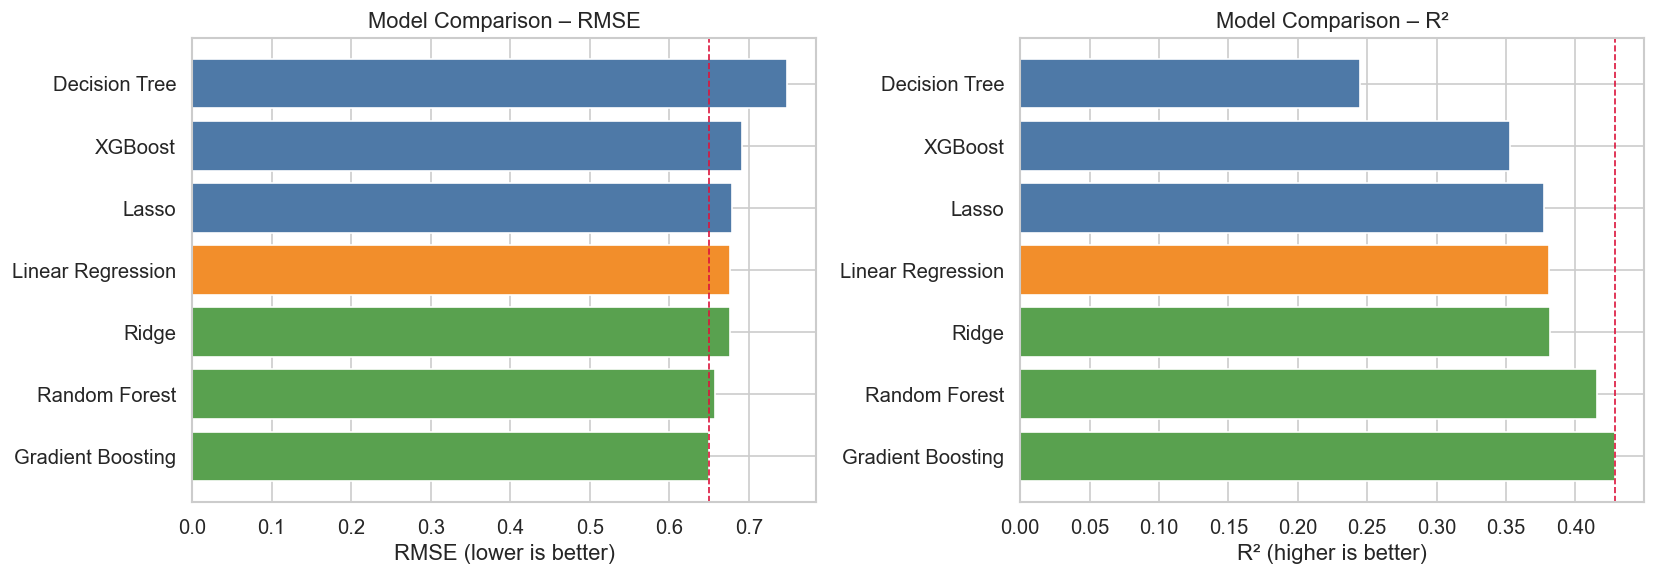

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4e79a7', '#4e79a7', '#4e79a7', '#f28e2b', '#59a14f', '#59a14f', '#59a14f']

results_sorted = results_df.sort_values('RMSE', ascending=True)

axes[0].barh(results_sorted.index, results_sorted['RMSE'], color=colors[::-1])
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('Model Comparison – RMSE')
axes[0].axvline(results_sorted['RMSE'].min(), color='crimson', linestyle='--', linewidth=1)

axes[1].barh(results_sorted.index, results_sorted['R²'], color=colors[::-1])
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('Model Comparison – R²')
axes[1].axvline(results_sorted['R²'].max(), color='crimson', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

### 5.7 Actual vs predicted

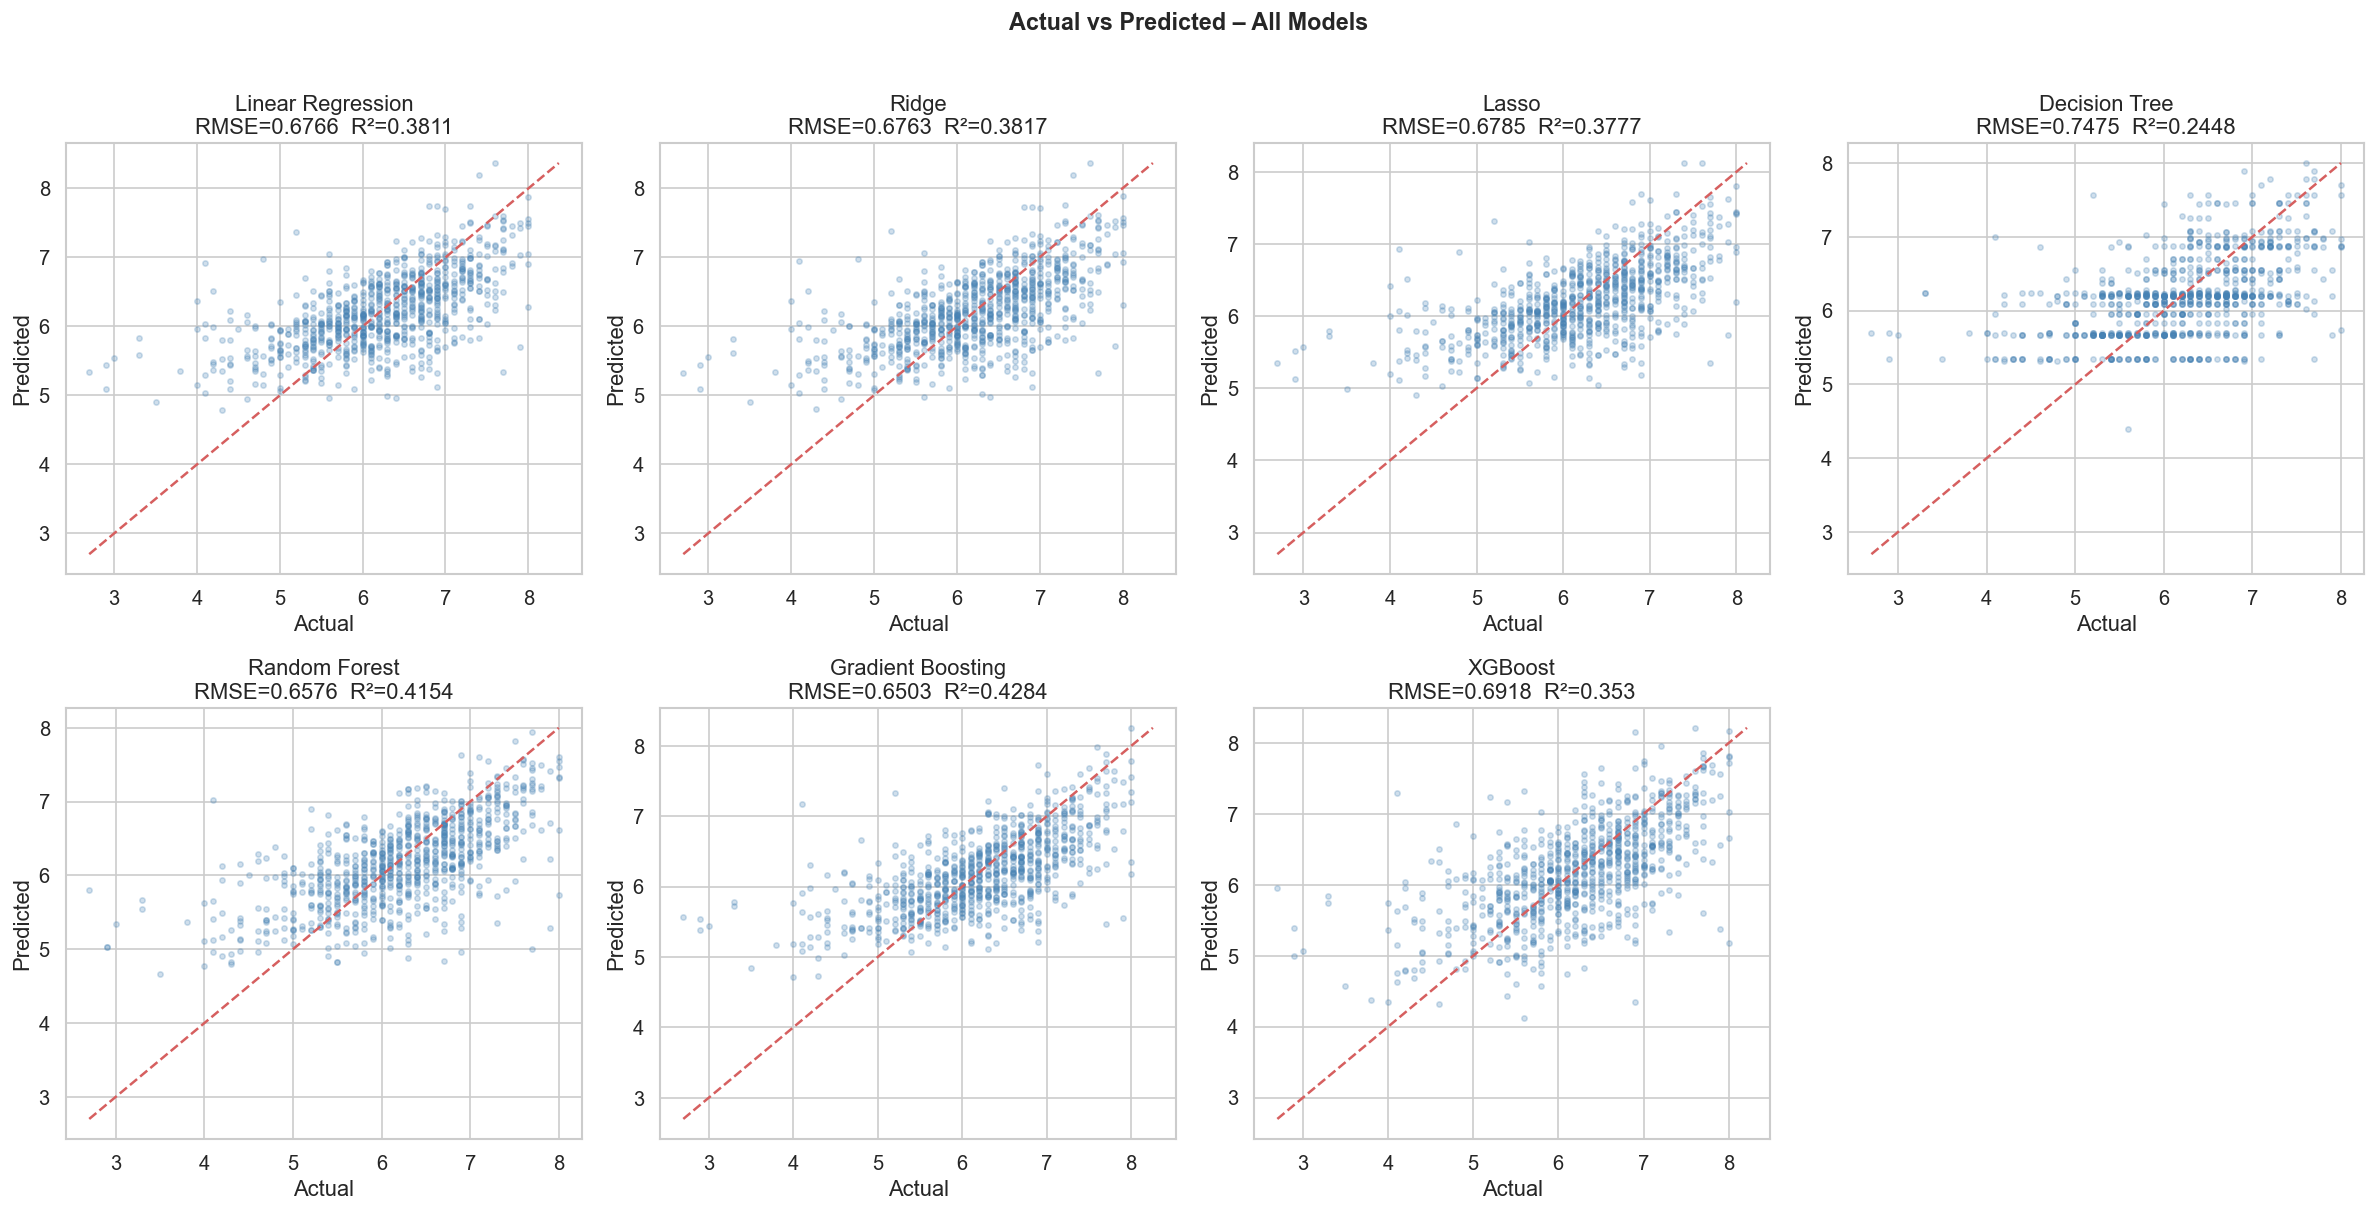

In [228]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test, y_pred, alpha=0.25, s=10, color='steelblue')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nRMSE={results[name]["RMSE"]}  R²={results[name]["R²"]}')

# hide the empty 8th subplot
axes[-1].set_visible(False)

plt.suptitle('Actual vs Predicted – All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.8 Residual plots

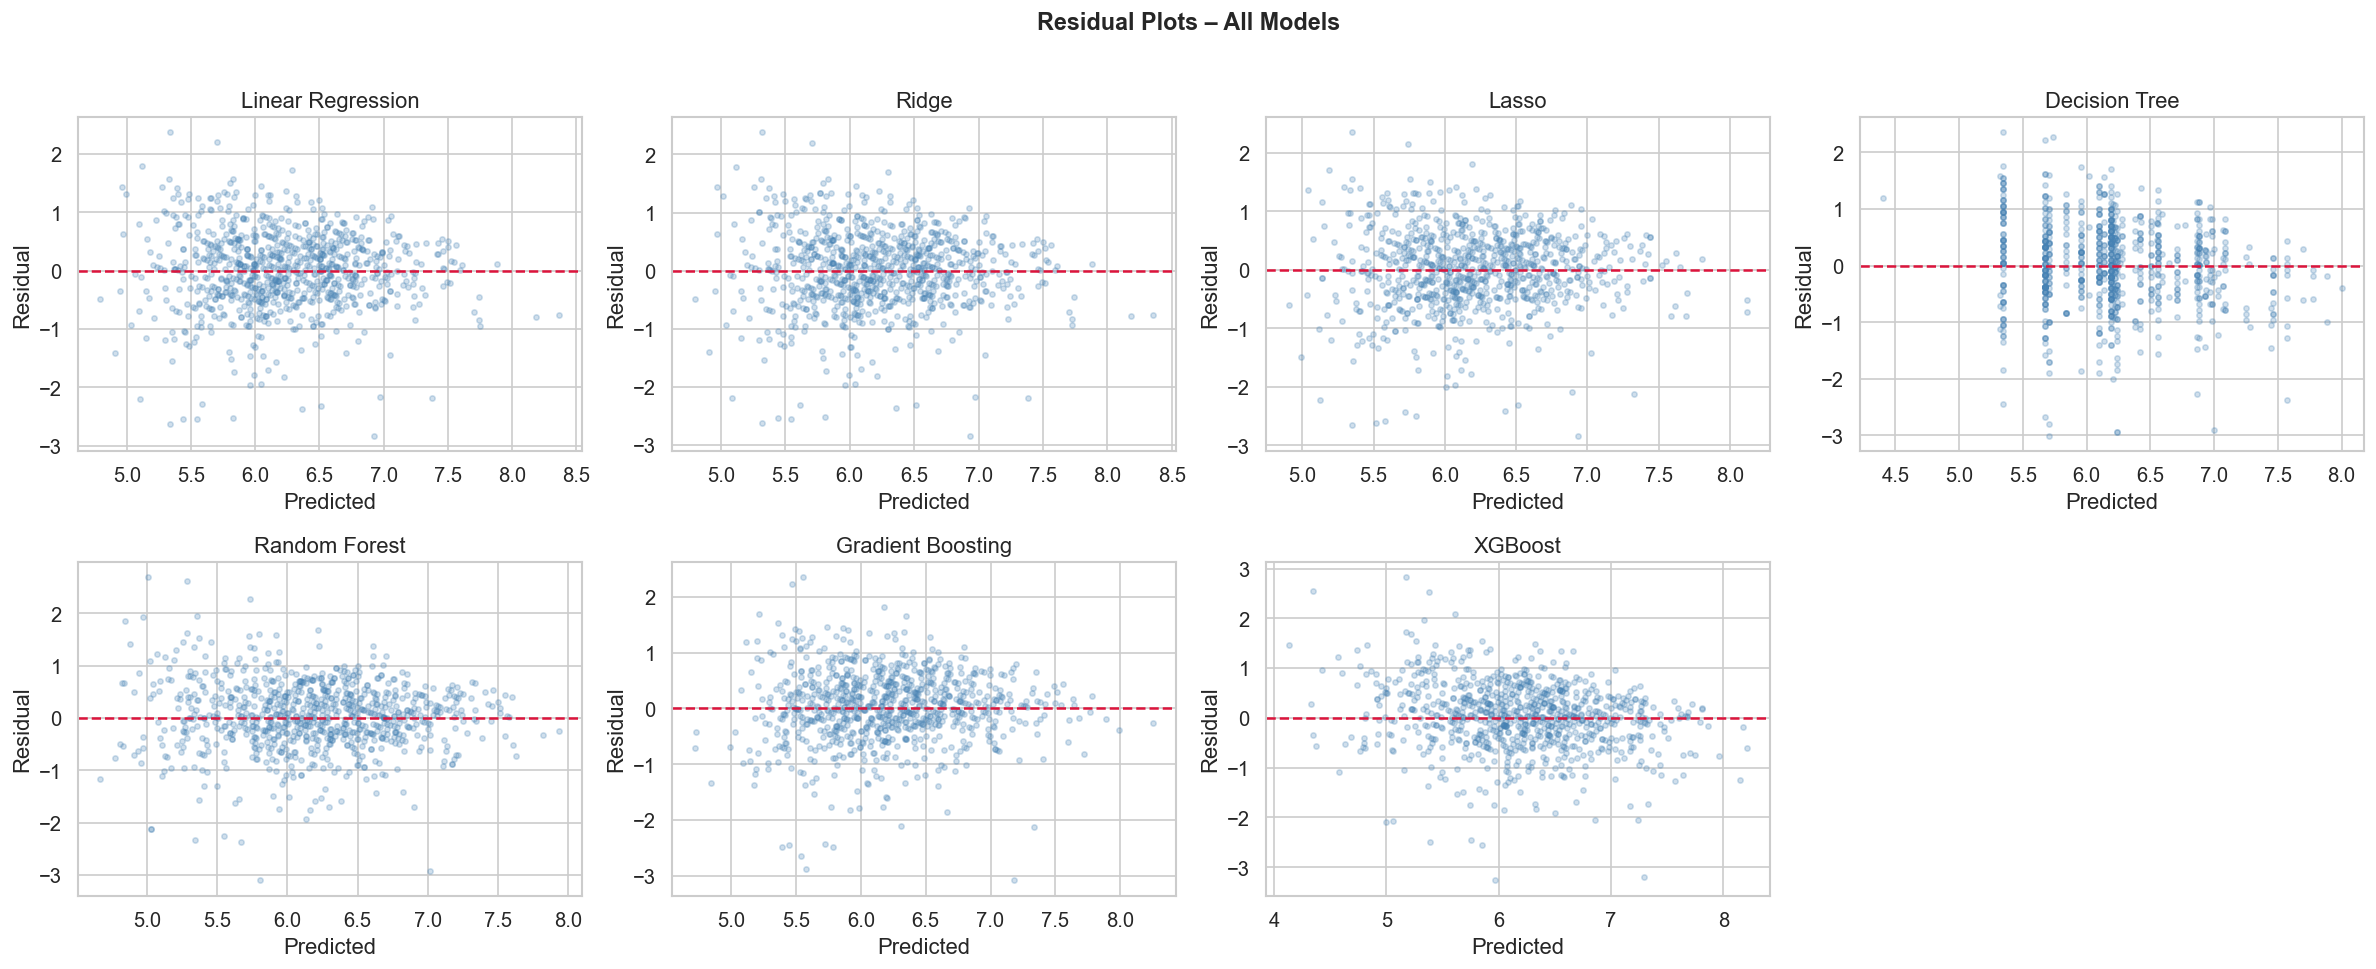

In [229]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, predictions.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.25, s=10, color='steelblue')
    ax.axhline(0, color='crimson', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')
    ax.set_title(name)

axes[-1].set_visible(False)

plt.suptitle('Residual Plots – All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 5.9 Feature importance – tree models

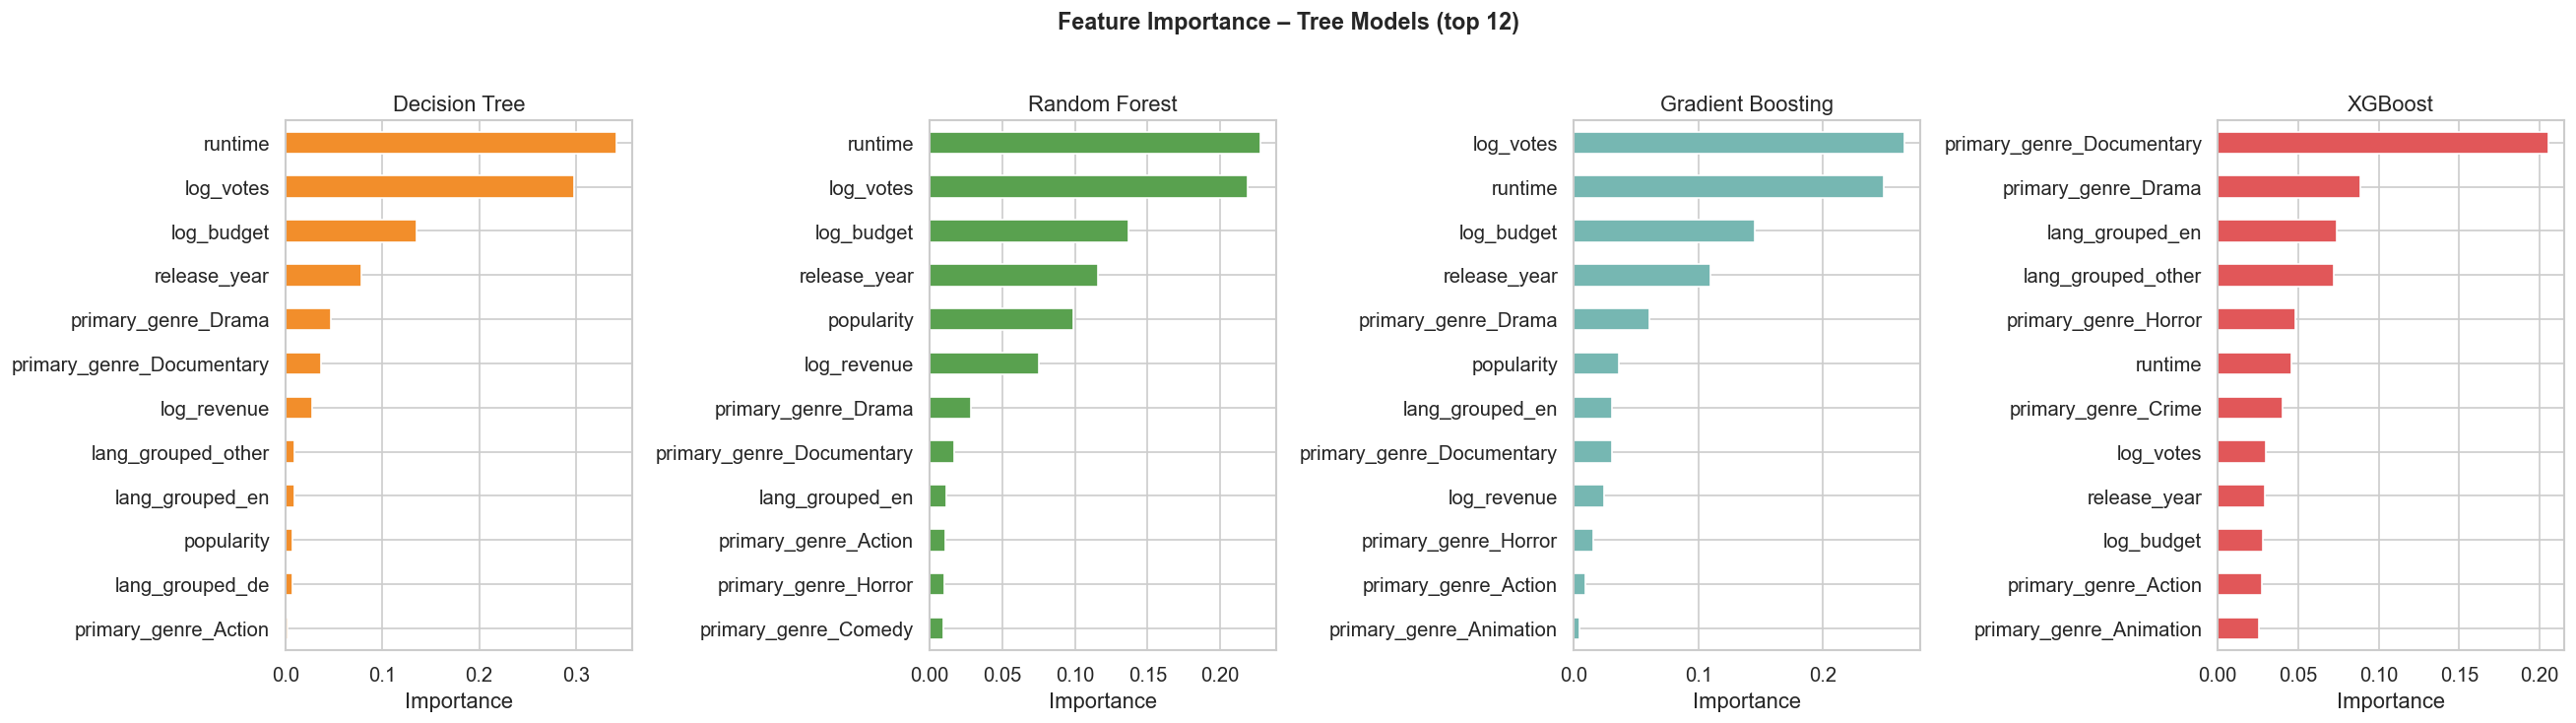

In [230]:
tree_models = {
    'Decision Tree':     trained['Decision Tree'],
    'Random Forest':     trained['Random Forest'],
    'Gradient Boosting': trained['Gradient Boosting'],
    'XGBoost':           trained['XGBoost'],
}
colors_imp = ['#f28e2b', '#59a14f', '#76b7b2', '#e15759']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, (name, model), color in zip(axes, tree_models.items(), colors_imp):
    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp = imp.sort_values(ascending=True).tail(12)
    imp.plot(kind='barh', ax=ax, color=color)
    ax.set_title(name)
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance – Tree Models (top 12)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.10 Linear model coefficients

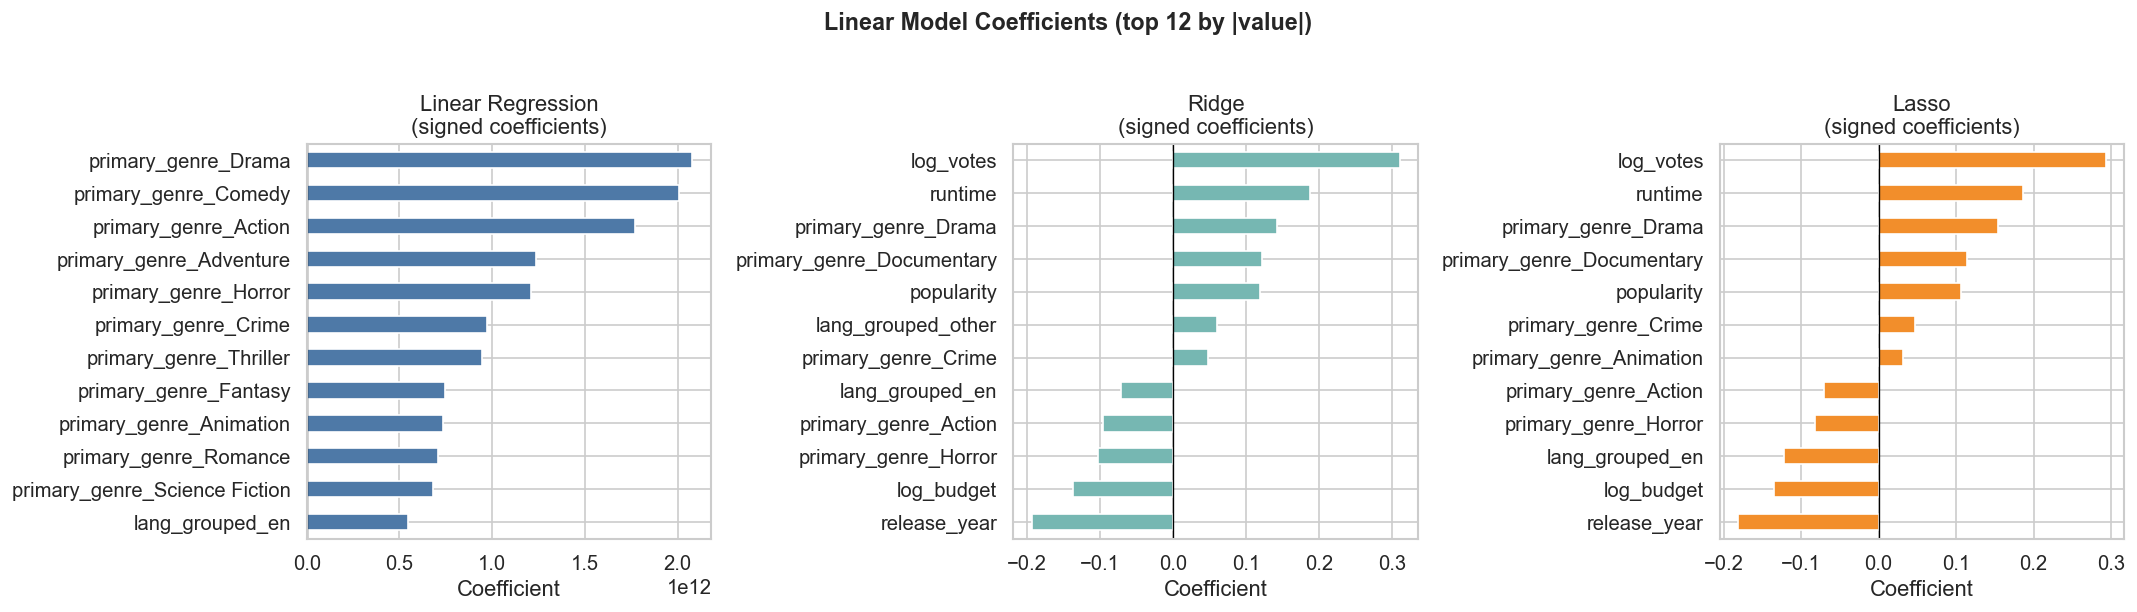

In [231]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

lin_models = ['Linear Regression', 'Ridge', 'Lasso']
colors_lin = ['#4e79a7', '#76b7b2', '#f28e2b']

for ax, name, color in zip(axes, lin_models, colors_lin):
    coef = pd.Series(trained[name].coef_, index=feature_names)
    coef_top = coef.abs().sort_values(ascending=True).tail(12)
    coef.loc[coef_top.index].sort_values().plot(kind='barh', ax=ax, color=color)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name}\n(signed coefficients)')
    ax.set_xlabel('Coefficient')

plt.suptitle('Linear Model Coefficients (top 12 by |value|)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.11 Summary

In [232]:
print(results_df.sort_values('RMSE').to_string())
print()

best = results_df['RMSE'].idxmin()
print(f'Best model : {best}')
print(f'  RMSE     : {results_df.loc[best, "RMSE"]}')
print(f'  R²       : {results_df.loc[best, "R²"]}')

                     RMSE      R²
Gradient Boosting  0.6503  0.4284
Random Forest      0.6576  0.4154
Ridge              0.6763  0.3817
Linear Regression  0.6766  0.3811
Lasso              0.6785  0.3777
XGBoost            0.6918  0.3530
Decision Tree      0.7475  0.2448

Best model : Gradient Boosting
  RMSE     : 0.6503
  R²       : 0.4284


---
## 6. Results & Discussion

### Model Comparison

| Model | RMSE | R² |
|---|---|---|
| **Gradient Boosting** | **0.6503** | **0.4284** |
| Random Forest | 0.6576 | 0.4154 |
| Ridge | 0.6763 | 0.3817 |
| Linear Regression | 0.6766 | 0.3811 |
| Lasso | 0.6785 | 0.3777 |
| XGBoost | 0.6918 | 0.3530 |
| Decision Tree | 0.7475 | 0.2448 |

The best model was **Gradient Boosting** with RMSE = 0.6503 and R² = 0.43, meaning predictions are off by about 0.65 rating points on average.

An R² of 0.43 is actually expected here. Movie ratings are subjective and things like screenplay quality or acting are not in the dataset, so the model can only go so far.

Some observations:
- Decision Tree alone had the worst result (R² = 0.24). Ensemble methods improved this significantly.
- Linear models (Ridge, LR, Lasso) performed surprisingly well, close to tree models. The relationship between features and ratings seems to be mostly linear.
- XGBoost underperformed compared to Gradient Boosting with default parameters. Hyperparameter tuning would likely improve it.
- The rankings stayed the same in 5-fold cross-validation, so the results are consistent.

### Feature Importance

`log_votes` (vote count) was the most important feature across all tree models, which is consistent with H1. Movies with more votes tend to be more popular and better rated.

`popularity`, `log_revenue`, and `runtime` were the next most important features. Genre had some effect but relatively small.

### Limitations

- `log_votes` is not available before a movie is released, so this model can't really be used for pre-release prediction.
- A large portion of budget and revenue data was missing, which likely hurt the model.
- No hyperparameter tuning was done — all models ran with default settings.